## Exploratory Data Analysis [EDA] - Supermarket_sales Dataset
    This project focuses on performing Exploratory Data Analysis (EDA) on the Supermarket Sales Dataset to uncover meaningful patterns, trends, and business insights. The analysis leverages. 
    
    The primary objective is to understand customer purchasing behavior, sales performance, and key factors influencing revenue across different branches, product lines, and time periods.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import numpy as np

## Loading the Dataset 

In [2]:
dt = pd.read_csv("supermarket_sales.csv")

## Look at the dataset first

In [3]:
dt.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,01-05-2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,03-08-2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,03-03-2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,02-08-2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


**Observation** :- The Dataset contains supermarket sales information including Payments, product catagoies, customer type, City, Product with Quantity and Rating. Details

In [4]:
warnings.filterwarnings('ignore')

###  Find Shape of Our Dataset (Number of Rows and Number Of Columns)

In [5]:
dt.shape

(1000, 17)

In [6]:
print('Number of Cols',dt.shape[0])
print('Number of Rows',dt.shape[1])

Number of Cols 1000
Number of Rows 17


- Each row represents an individual Supermarket Sales record
- Each column represents Sales Components
- the dataset size indicates it is suitable for exploratory analysis

### Check For Null Values In The Dataset

In [7]:
dt.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

- The Dataset contains zero amount of null values 
- If some of the column doesn't have that much importance like status and Notes so we can drop the entire column

### Get Information About Our Dataset Like Total Number Rows, Total Number of Columns, Datatypes of Each Column And Memory Requirement

In [8]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

- Zero columns are non-null
- Data types are appropriate for analysis
- Most columns are numerical, while sales-related fields are categorical.


###  Get Overall Statistics About The Dataset

In [9]:
dt.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1.000000e+03,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905e+00,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,6.131498e-14,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905e+00,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905e+00,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905e+00,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905e+00,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905e+00,49.650000,10.00000


- Sales-related , The dataset has 1000 complete records with balanced price and quantity distributions, wide variation in total sales, consistent tax and profit calculations, generally positive ratings, and one non-informative constant feature (gross margin %) that can be excluded.

In [10]:
cat=[]
num=[]
for column in dt.columns:
    if dt[column].nunique() > 10:
        num.append(column)
    else:
        cat.append(column)

In [11]:
cat


['Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Quantity',
 'Payment',
 'gross margin percentage']

In [12]:
num

['Invoice ID',
 'Unit price',
 'Tax 5%',
 'Total',
 'Date',
 'Time',
 'cogs',
 'gross income',
 'Rating']

#### 1. Find Aggregate Sales Among Branches. (Categorical Column)

<Axes: xlabel='City', ylabel='count'>

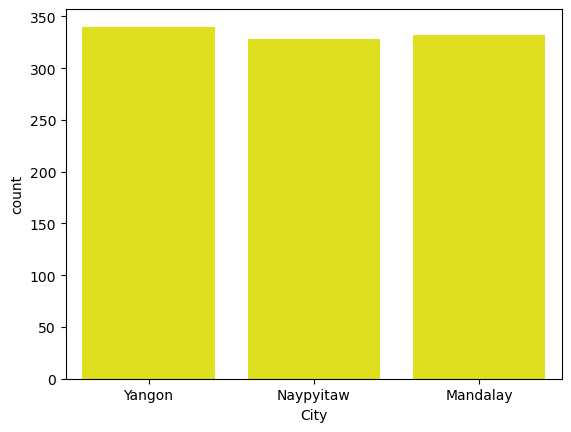

In [13]:
sns.countplot(x=dt["City"], color="yellow")

<Axes: xlabel='Quantity'>

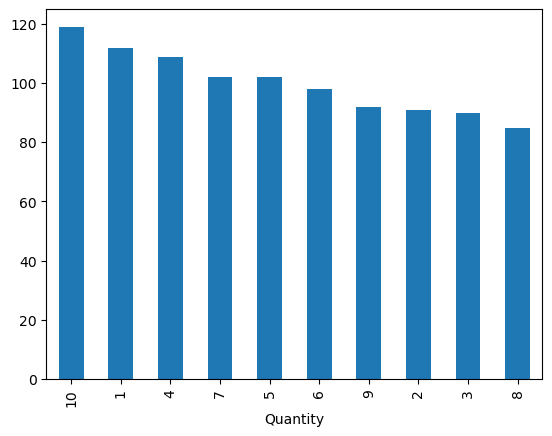

In [14]:
dt['Quantity'].value_counts().plot(kind='bar')

#### 2.Find The Most Popular Payment Method Used By Customers (Categorical Column)

<Axes: xlabel='Payment'>

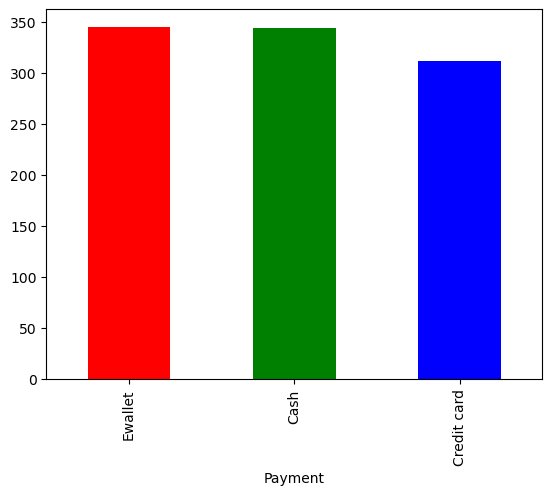

In [15]:
dt['Payment'].value_counts().plot(
    kind='bar',
    color=['red', 'green', 'blue']
)

#### 3. Find The Distribution of  Gross Income. (Numerical Column)

<Axes: xlabel='gross income', ylabel='Density'>

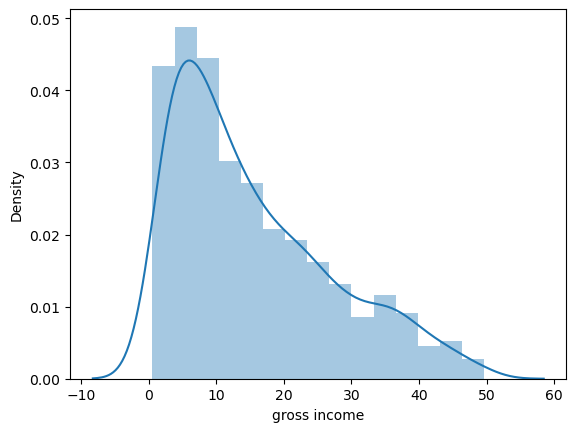

In [16]:
sns.distplot(dt['gross income'])

In [17]:
dt['gross income'].skew()

np.float64(0.8925698049581423)

#### 4. Find the Distribution of Cost of Goods Sold (Numerical Column)

<Axes: xlabel='cogs', ylabel='Density'>

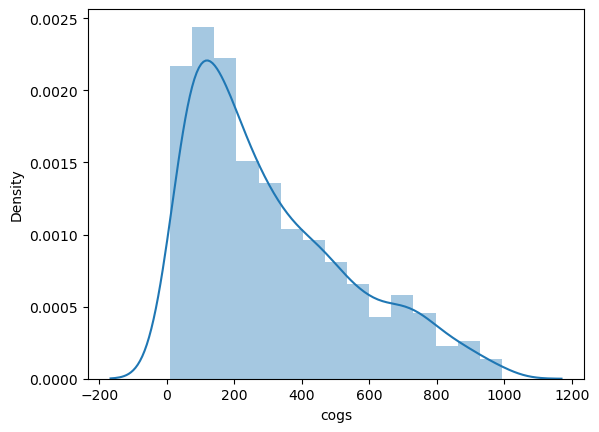

In [18]:
sns.distplot(dt['cogs'])

In [19]:
dt['cogs'].skew()

np.float64(0.8925698049581418)

#### 1. Does The Cost of Goods Sold Affect The Ratings That The Customers Provide? (Numerical - Numerical)

In [20]:
cat

['Branch',
 'City',
 'Customer type',
 'Gender',
 'Product line',
 'Quantity',
 'Payment',
 'gross margin percentage']

In [21]:
num

['Invoice ID',
 'Unit price',
 'Tax 5%',
 'Total',
 'Date',
 'Time',
 'cogs',
 'gross income',
 'Rating']

<Axes: xlabel='cogs', ylabel='Rating'>

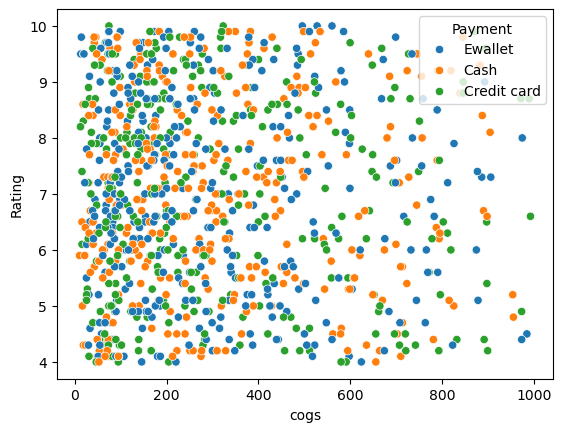

In [22]:
sns.scatterplot(x='cogs', y='Rating', data=dt, hue='Payment')

#### 2. Does Gross Income Affect The Ratings That The Customers Provide? (Numerical - Numerical)

<Axes: xlabel='cogs', ylabel='Rating'>

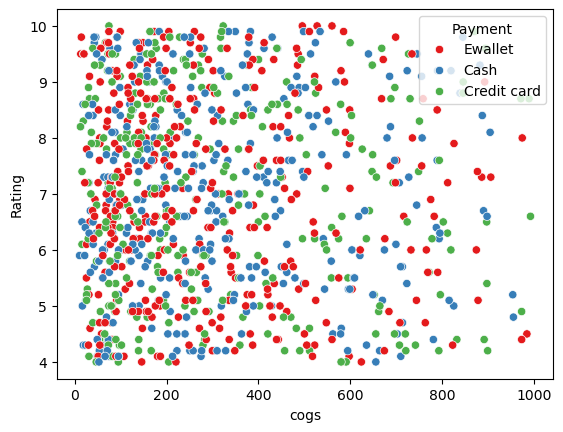

In [23]:
sns.scatterplot(
    x='cogs',
    y='Rating',
    data=dt,
    hue='Payment',
    palette='Set1'
)

#### 3. Find The Most Profitable Branch As Per Gross Income. (Numerical - Categorical)

<Axes: xlabel='Branch', ylabel='gross income'>

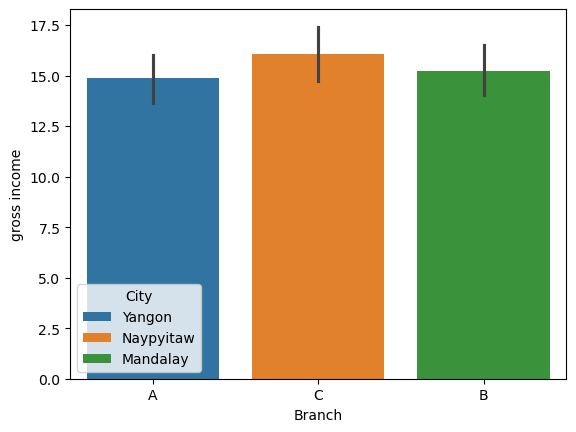

In [24]:
sns.barplot(x = 'Branch', y = 'gross income', data = dt, hue = dt['City'])


#### 4. Find The Product Line That Generates The Most Income. (Numerical - Categorical)

In [25]:
dt.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

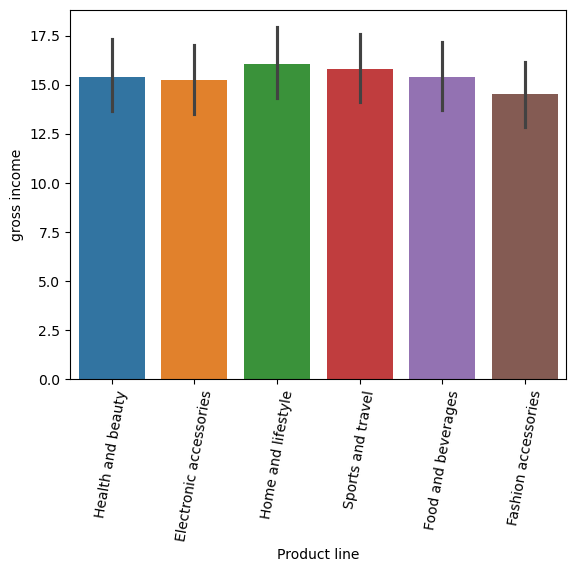

In [26]:
sns.barplot(x = 'Product line', y = 'gross income', data = dt, hue = dt['Product line'])
plt.xticks(rotation = 80)
plt.show()

#### 5. Find The Highest Unit Price In The Product Line. (Numerical - Categorical)

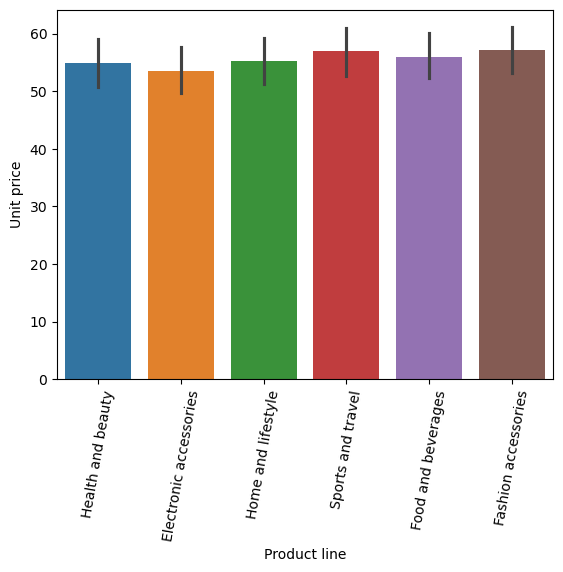

In [27]:
sns.barplot(x = 'Product line', y = 'Unit price', data = dt, hue = dt['Product line'])
plt.xticks(rotation = 80)
plt.show()

#### 6. Find Different Payment Methods Used By Customers Citywise.(Categorical -Categorical)

In [28]:
pd.crosstab(dt['City'], dt['Payment'])

Payment,Cash,Credit card,Ewallet
City,,,
Mandalay,110,109,113
Naypyitaw,124,98,106
Yangon,110,104,126


<Axes: xlabel='Payment', ylabel='City'>

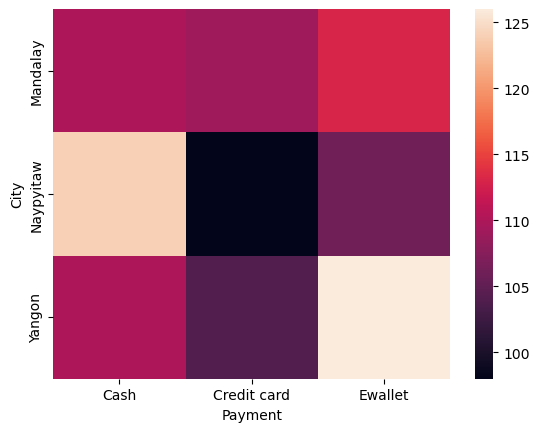

In [29]:
sns.heatmap(pd.crosstab(dt['City'], dt['Payment']))

#### 7. Which Product Line Is Purchased In The Highest Quantity?

In [30]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

#### 8. Display Daily Sales by Day of the Week

In [37]:
dt.columns

Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Total', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='object')

In [38]:
dw_mapping ={
    0:'Mon',
    1:'Tue',
    2:'Wed',
    3:'Thur',
    4:'Fri',
    5:'Sat',
    6:'Sun',
    
}

In [45]:
dt = pd.read_csv("supermarket_sales.csv")

# 🔥 ADD THIS LINE (MISSING IN YOUR FILE)
dt['Date'] = pd.to_datetime(dt['Date'], errors='coerce')

# Now this will work
dt['day_of_week'] = dt['Date'].dt.dayofweek.map(dw_mapping)

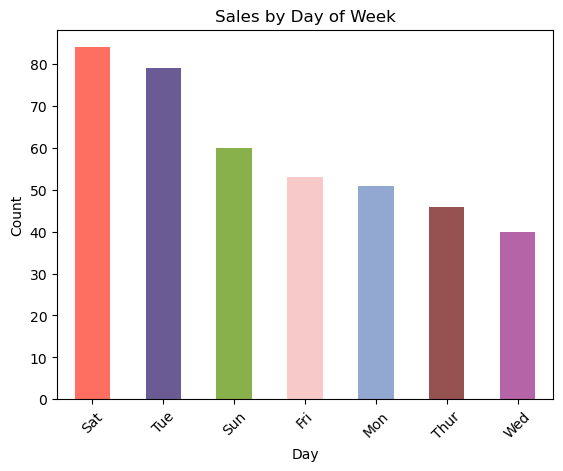

In [46]:
dt['day_of_week'].value_counts().plot(
    kind='bar',
    color=['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1', '#955251', '#B565A7']
)

plt.title("Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

#### 10. What Will Be the Highest Months for Sales

In [47]:
month_mapping ={
    1:'Jan',
    2:'Feb',
    3:'March',   
}

In [48]:
dt['month'] = dt['Date'].dt.month.map(month_mapping)

<Axes: xlabel='month'>

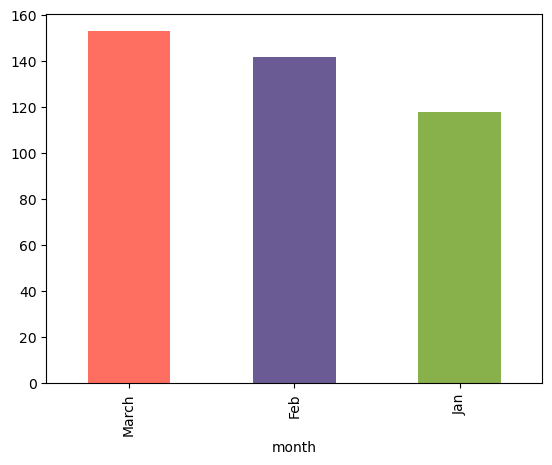

In [49]:
dt['month'].value_counts().plot(kind = 'bar', color=['#FF6F61', '#6B5B95', '#88B04B'])
